### Residual detection
we want to separate residual heat and human
We decompose it into several steps
1. separate heat patches from different objects
2. classify which is human, which is not.

## Loading example of human + residual

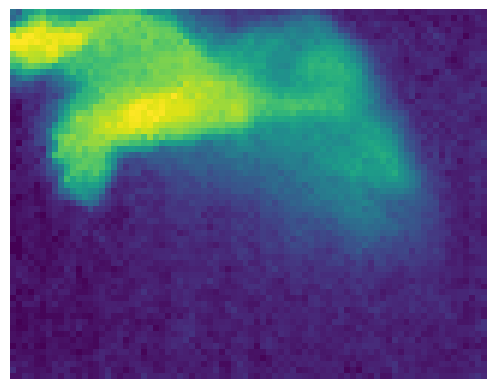

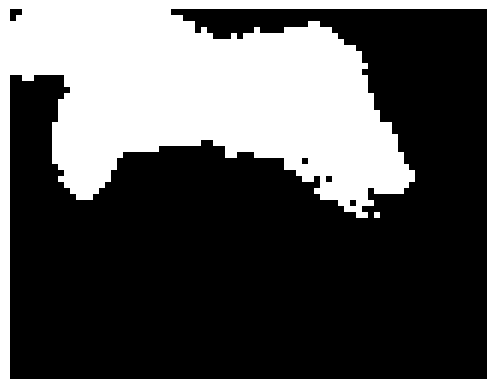

In [ ]:
import os
import sys
sys.path.append('../..') # to allow import from src.
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)  # Suppress DEBUG and INFO messages
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from src.heat_patch_tracker_module.kalman_blob import KalmanBlob, mask_to_bbox
from scipy.optimize import linear_sum_assignment
from src.data_collection_module import utils



from src.organizer_module.track_kalman import Tracker

# use data from hall1, frame 18055-18115 for testing

from src.dataset import ThermalDataset
from src.heatsource_detection_module.extract import HeatSourceDetector

idx = 10497
dataset = ThermalDataset("/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/hall1")
detector = HeatSourceDetector()
tracker = Tracker()

ira_highres = dataset.get_ira_highres(idx)
# rotate image 180 degrees
ira_highres = cv2.rotate(ira_highres, cv2.ROTATE_180)
thresh, mask = detector.get_thresh_mask_otsu(ira_highres)
cleaned_mask = detector.get_connected_components(mask, min_size=10)
# turn off axes for plt
plt.axis('off')
plt.imshow(ira_highres)
plt.show()
plt.axis('off')
plt.imshow(mask, cmap='gray')
plt.show()

tracker.update_blobs(cleaned_mask, ira_highres, detector.get_unmasked_mean(ira_highres, mask), idx)

ira_color = utils.colorize_thermal_map(ira_highres)
IRA_height, IRA_width = ira_highres.shape
ira_color = cv2.resize(ira_color, (IRA_width*5, IRA_height*5), interpolation=cv2.INTER_NEAREST)
for i, blob in enumerate(tracker.blobs):
    if len(blob.kalman_centroid_history) == 0:
        continue
    cX, cY = blob.kalman_centroid_history[-1]
    cv2.putText(ira_color, str(blob.id), (int(cX)*5, int(cY)*5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

# how thermal images differentiate human and heat interference


In [ ]:
# we can obtain mask from thresholding and mask from vision
# then we OR them together to get a mask of human only.